# 15. FastSurfer Volumes Aggregation

## Obiettivo
- Verificare la completezza dei risultati FastSurfer per tutti i dataset
- Estrarre i volumi regionali dai file `stats/aseg+DKT.stats`
- Aggregare i volumi in CSV per dataset, compatibili con il formato esistente in `/data/volumes/`

## Dataset
| Dataset | Soggetti attesi | Path output (effettivo) |
|---------|----------------|--------------------------|
| ADNI    | 409 | `ADNI/derivatives/fastsurfer/` |
| IXI     | 563 | `IXI/derivatives/fastsurfer/` |
| OASIS2  | 85  | `OASIS/derivatives/fastsurfer/OASIS2/` |
| OASIS3  | 918 | `OASIS/derivatives/fastsurfer/OASIS3/` |
| PPMI    | 187 | `PPMI/nifti_baseline/derivatives/fastsurfer/` |
| SRPBS   | 251 | `SRPBS/SRPBS_BIDS/derivatives/fastsurfer/` |
| AABC    | 347 | `AABC/derivatives/fastsurfer/` |
| FOMO    | ~640 | `FOMO/derivatives/fastsurfer/ds-PT*/` |

## Nota
Le path FastSurfer sopra sono gia` valide nel NAS corrente e separate dalle path SynthSeg (notebook 8).

## 1. Setup

In [29]:
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path

NAS_ROOT = Path("/mnt/NAS-Progetti/BrainAtrophy/Normative Model")
OUTPUT_DIR = Path("/home/mario/Repository/Normal_Alzeihmer/data/volumes")

# Paths derivatives/fastsurfer per dataset
FASTSURFER_PATHS = {
    "adni":   NAS_ROOT / "ADNI/derivatives/fastsurfer",
    "ixi":    NAS_ROOT / "IXI/derivatives/fastsurfer",
    "oasis2": NAS_ROOT / "OASIS/derivatives/fastsurfer/OASIS2",
    "oasis3": NAS_ROOT / "OASIS/derivatives/fastsurfer/OASIS3",
    "ppmi":   NAS_ROOT / "PPMI/nifti_baseline/derivatives/fastsurfer",
    "srpbs":  NAS_ROOT / "SRPBS/SRPBS_BIDS/derivatives/fastsurfer",
    "aabc":   NAS_ROOT / "AABC/derivatives/fastsurfer",
    "fomo":   NAS_ROOT / "FOMO/derivatives/fastsurfer",
}

# File marker di completamento FastSurfer
COMPLETION_FILES = [
    "mri/aparc.DKTatlas+aseg.deep.mgz",
    "stats/aseg+DKT.stats",
    "mri/orig.mgz",
]

## 2. Verifica completezza

Controlla quanti soggetti sono stati processati correttamente per ogni dataset.

In [16]:
def find_completed_subjects(base_path: Path) -> list[Path]:
    """Trova cartelle di processamento FastSurfer complete.
    Supporta strutture flat (subject/) e annidate con sessioni (subject/ses-XX/).
    """
    completed = []

    def is_complete(path: Path) -> bool:
        return all((path / f).exists() for f in COMPLETION_FILES)

    for candidate in sorted(base_path.rglob("stats/aseg+DKT.stats")):
        processing_dir = candidate.parent.parent  # risale da stats/ alla dir di processamento
        if is_complete(processing_dir):
            completed.append(processing_dir)

    return completed


def extract_subject_and_session_id(processing_dir: Path) -> tuple[str, str | None]:
    """Estrae subject_id/session_id da path FastSurfer, anche in layout annidati."""
    subject_id = None
    session_id = None

    # Cerca token BIDS-like nel path (sub-*, ses-*)
    for part in reversed(processing_dir.parts):
        if session_id is None and part.startswith("ses-"):
            session_id = part
        if subject_id is None and part.startswith("sub-"):
            subject_id = part

    # Fallback per ID non-BIDS (es. ADNI 002_S_0295, IXI123, HCA...)
    if subject_id is None:
        for part in reversed(processing_dir.parts):
            if "_S_" in part or part.startswith("IXI") or part.startswith("HCA"):
                subject_id = part
                break

    # Ultimo fallback: usa la cartella corrente (flat layout)
    if subject_id is None:
        if session_id is not None and processing_dir.parent.name:
            subject_id = processing_dir.parent.name
        else:
            subject_id = processing_dir.name

    return subject_id, session_id


print("=" * 60)
print("COMPLETEZZA FASTSURFER PER DATASET")
print("=" * 60)

completed_subjects = {}
for dataset, path in FASTSURFER_PATHS.items():
    if not path.exists():
        print(f"{dataset.upper():10s}: PATH NON TROVATO - {path}")
        completed_subjects[dataset] = []
        continue
    subjects = find_completed_subjects(path)
    completed_subjects[dataset] = subjects
    print(f"{dataset.upper():10s}: {len(subjects):4d} soggetti completati")

total = sum(len(v) for v in completed_subjects.values())
print(f"{'TOTALE':10s}: {total:4d} soggetti")

COMPLETEZZA FASTSURFER PER DATASET
ADNI      :  409 soggetti completati
IXI       :  563 soggetti completati
OASIS2    :   85 soggetti completati
OASIS3    :  827 soggetti completati
PPMI      :  181 soggetti completati
SRPBS     :  251 soggetti completati
AABC      :  347 soggetti completati
FOMO      :  853 soggetti completati
TOTALE    : 3516 soggetti


## 3. Parsing del file aseg+DKT.stats

Il file `stats/aseg+DKT.stats` è in formato FreeSurfer stats.
Le righe dati iniziano senza `#` e hanno il formato:
```
Index SegId NVoxels Volume_mm3 StructName normMean normStdDev normMin normMax normRange
```
Estraiamo `Volume_mm3` per ogni struttura, producendo le stesse colonne del formato SynthSeg esistente.

In [17]:
# Mapping nomi strutture FastSurfer -> colonne CSV esistenti (formato SynthSeg)
STRUCTURE_MAP = {
    # Subcortical
    "Left-Lateral-Ventricle":     "vol_left lateral ventricle",
    "Left-Inf-Lat-Vent":          "vol_left inferior lateral ventricle",
    "Left-Cerebellum-White-Matter": "vol_left cerebellum white matter",
    "Left-Cerebellum-Cortex":     "vol_left cerebellum cortex",
    "Left-Thalamus":              "vol_left thalamus",
    "Left-Caudate":               "vol_left caudate",
    "Left-Putamen":               "vol_left putamen",
    "Left-Pallidum":              "vol_left pallidum",
    "3rd-Ventricle":              "vol_3rd ventricle",
    "4th-Ventricle":              "vol_4th ventricle",
    "Brain-Stem":                 "vol_brain-stem",
    "Left-Hippocampus":           "vol_left hippocampus",
    "Left-Amygdala":              "vol_left amygdala",
    "CSF":                        "vol_csf",
    "Left-Accumbens-area":        "vol_left accumbens area",
    "Left-VentralDC":             "vol_left ventral DC",
    "Right-Lateral-Ventricle":    "vol_right lateral ventricle",
    "Right-Inf-Lat-Vent":         "vol_right inferior lateral ventricle",
    "Right-Cerebellum-White-Matter": "vol_right cerebellum white matter",
    "Right-Cerebellum-Cortex":    "vol_right cerebellum cortex",
    "Right-Thalamus":             "vol_right thalamus",
    "Right-Caudate":              "vol_right caudate",
    "Right-Putamen":              "vol_right putamen",
    "Right-Pallidum":             "vol_right pallidum",
    "Right-Hippocampus":          "vol_right hippocampus",
    "Right-Amygdala":             "vol_right amygdala",
    "Right-Accumbens-area":       "vol_right accumbens area",
    "Right-VentralDC":            "vol_right ventral DC",
    # Global
    "Left-Cerebral-White-Matter": "vol_left cerebral white matter",
    "Left-Cerebral-Cortex":       "vol_left cerebral cortex",
    "Right-Cerebral-White-Matter": "vol_right cerebral white matter",
    "Right-Cerebral-Cortex":      "vol_right cerebral cortex",
}

# Mapping regioni corticali DKT
DKT_REGIONS = [
    "bankssts", "caudalanteriorcingulate", "caudalmiddlefrontal", "cuneus",
    "entorhinal", "fusiform", "inferiorparietal", "inferiortemporal",
    "isthmuscingulate", "lateraloccipital", "lateralorbitofrontal", "lingual",
    "medialorbitofrontal", "middletemporal", "parahippocampal", "paracentral",
    "parsopercularis", "parsorbitalis", "parstriangularis", "pericalcarine",
    "postcentral", "posteriorcingulate", "precentral", "precuneus",
    "rostralanteriorcingulate", "rostralmiddlefrontal", "superiorfrontal",
    "superiorparietal", "superiortemporal", "supramarginal", "frontalpole",
    "temporalpole", "transversetemporal", "insula",
]
for region in DKT_REGIONS:
    STRUCTURE_MAP[f"ctx-lh-{region}"] = f"vol_ctx-lh-{region}"
    STRUCTURE_MAP[f"ctx-rh-{region}"] = f"vol_ctx-rh-{region}"


def parse_measure_line(line: str) -> tuple[str | None, str | None, float | None]:
    """Parsa una riga '# Measure ...' e restituisce (nome_lungo, nome_breve, valore)."""
    if not line.startswith("# Measure"):
        return None, None, None

    payload = line.replace("# Measure", "", 1).strip()
    parts = [p.strip() for p in payload.split(",")]
    if len(parts) < 4:
        return None, None, None

    long_name = parts[0]
    short_name = parts[1]
    try:
        value = float(parts[3])
    except ValueError:
        value = None
    return long_name, short_name, value


def parse_stats_file(stats_path: Path) -> dict:
    """Legge aseg+DKT.stats e restituisce un dict {col_name: volume_mm3}."""
    volumes = {}
    etiv = np.nan

    with open(stats_path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("# Measure"):
                long_name, short_name, value = parse_measure_line(line)
                if value is not None:
                    # Naming FreeSurfer: eTIV (Estimated Total Intracranial Volume), aka ICV.
                    if short_name in {"EstimatedTotalIntraCranialVol", "eTIV", "ICV", "IntraCranialVol"}:
                        etiv = value
                    # Fallback per output FastSurfer privi di eTIV esplicito.
                    elif short_name == "MaskVol" and np.isnan(etiv):
                        etiv = value

            if line.startswith("#") or not line.strip():
                continue

            parts = line.split()
            if len(parts) < 5:
                continue

            struct_name = parts[4]
            try:
                volume_mm3 = float(parts[3])
            except ValueError:
                continue

            if struct_name in STRUCTURE_MAP:
                volumes[STRUCTURE_MAP[struct_name]] = volume_mm3

    # Colonne standard FreeSurfer + compatibilita` retroattiva con pipeline esistente.
    volumes["eTIV"] = etiv
    volumes["ICV"] = etiv
    volumes["vol_total intracranial"] = etiv
    return volumes


# Test su un soggetto ADNI
example_subject = completed_subjects["adni"][0] if completed_subjects["adni"] else None
if example_subject:
    example_stats = parse_stats_file(example_subject / "stats/aseg+DKT.stats")
    sid, ses = extract_subject_and_session_id(example_subject)
    print(f"Esempio processing dir: {example_subject}")
    print(f"subject_id: {sid}")
    print(f"session_id: {ses}")
    print(f"Strutture estratte: {len(example_stats)}")
    print(f"eTIV (aka ICV): {example_stats.get('eTIV')} mm^3")
    print(f"Ippocampo sx: {example_stats.get('vol_left hippocampus')} mm^3")
    print(f"Ippocampo dx: {example_stats.get('vol_right hippocampus')} mm^3")

Esempio processing dir: /mnt/NAS-Progetti/BrainAtrophy/Normative Model/ADNI/derivatives/fastsurfer/002_S_0295
subject_id: 002_S_0295
session_id: None
Strutture estratte: 95
eTIV (aka ICV): 1471799.0 mm^3
Ippocampo sx: 3623.491 mm^3
Ippocampo dx: 3824.445 mm^3


## 4. Aggrega volumi per dataset

In [26]:
def aggregate_dataset(subject_dirs: list[Path], dataset_name: str) -> pd.DataFrame:
    """Aggrega i volumi FastSurfer per tutti i soggetti di un dataset."""
    records = []
    errors = []

    for processing_dir in subject_dirs:
        stats_file = processing_dir / "stats/aseg+DKT.stats"
        try:
            vols = parse_stats_file(stats_file)
            subject_id, session_id = extract_subject_and_session_id(processing_dir)
            vols["subject_id"] = subject_id
            if session_id is not None:
                vols["session_id"] = session_id
            records.append(vols)
        except Exception as e:
            errors.append(f"{processing_dir}: {e}")

    if errors:
        print(f"  {dataset_name} - {len(errors)} errori:")
        for err in errors[:5]:
            print(f"    {err}")

    if not records:
        return pd.DataFrame(columns=["subject_id"])

    df = pd.DataFrame(records)

    # Se ci sono piu` sessioni per lo stesso soggetto, tieni la prima in ordine lessicografico.
    if "subject_id" in df.columns and df["subject_id"].duplicated().any():
        n_dup = int(df["subject_id"].duplicated().sum())
        print(f"  {dataset_name} - trovati {n_dup} duplicati subject_id (sessioni multiple), deduplica in corso")
        sort_cols = [c for c in ["subject_id", "session_id"] if c in df.columns]
        df = df.sort_values(sort_cols).drop_duplicates(subset="subject_id", keep="first")

    # Derivate utili per rivalutazione modello normativo.
    if {"vol_left hippocampus", "vol_right hippocampus"}.issubset(df.columns):
        df["vol_total_hippocampus"] = df["vol_left hippocampus"] + df["vol_right hippocampus"]

    if {"vol_left inferior lateral ventricle", "vol_right inferior lateral ventricle"}.issubset(df.columns):
        df["vol_total inferior lateral ventricle"] = (
            df["vol_left inferior lateral ventricle"] + df["vol_right inferior lateral ventricle"]
        )

    if {"vol_total inferior lateral ventricle", "vol_total_hippocampus"}.issubset(df.columns):
        denom = df["vol_total_hippocampus"].replace(0, np.nan)
        df["ilv_to_hippocampal_ratio"] = df["vol_total inferior lateral ventricle"] / denom

    # Metti subject_id (e session_id se presente) in coda per leggibilita`.
    tail_cols = [c for c in ["session_id", "subject_id"] if c in df.columns]
    cols = [c for c in df.columns if c not in tail_cols] + tail_cols
    return df[cols]


print("Aggregazione volumi...\n")
aggregated = {}
for dataset, subjects in completed_subjects.items():
    if not subjects:
        print(f"{dataset.upper():10s}: nessun soggetto completato, skip")
        continue
    df = aggregate_dataset(subjects, dataset)
    aggregated[dataset] = df
    print(f"{dataset.upper():10s}: {df.shape[0]} soggetti x {df.shape[1]} colonne")

print("\nQA eTIV/ICV:")
for dataset, df in aggregated.items():
    etiv_col = "eTIV" if "eTIV" in df.columns else "vol_total intracranial"
    if etiv_col not in df.columns or len(df) == 0:
        print(f"  {dataset.upper():10s}: colonna assente")
        continue
    etiv = df[etiv_col]
    nan_pct = 100.0 * etiv.isna().sum() / len(df)
    print(
        f"  {dataset.upper():10s}: NaN={nan_pct:5.1f}% | mean={etiv.mean():.0f} | min={etiv.min():.0f} | max={etiv.max():.0f}"
    )

print("\nQA ILV/Hippocampus ratio:")
for dataset, df in aggregated.items():
    if "ilv_to_hippocampal_ratio" not in df.columns or len(df) == 0:
        print(f"  {dataset.upper():10s}: colonna assente")
        continue
    ratio = df["ilv_to_hippocampal_ratio"]
    nan_pct = 100.0 * ratio.isna().sum() / len(df)
    print(
        f"  {dataset.upper():10s}: NaN={nan_pct:5.1f}% | mean={ratio.mean():.4f} | median={ratio.median():.4f} | p95={ratio.quantile(0.95):.4f}"
    )

Aggregazione volumi...

ADNI      : 409 soggetti x 99 colonne
IXI       : 563 soggetti x 99 colonne
OASIS2    : 85 soggetti x 99 colonne
OASIS3    : 827 soggetti x 99 colonne
PPMI      : 181 soggetti x 100 colonne
SRPBS     : 251 soggetti x 99 colonne
AABC      : 347 soggetti x 99 colonne
  fomo - trovati 145 duplicati subject_id (sessioni multiple), deduplica in corso
FOMO      : 708 soggetti x 100 colonne

QA eTIV/ICV:
  ADNI      : NaN=  0.0% | mean=1383066 | min=1064511 | max=1785638
  IXI       : NaN=  0.0% | mean=1396744 | min=1038740 | max=1805446
  OASIS2    : NaN=  0.0% | mean=1378919 | min=1103383 | max=1797862
  OASIS3    : NaN=  0.0% | mean=1369297 | min=611531 | max=1821682
  PPMI      : NaN=  0.0% | mean=1422785 | min=1038661 | max=1788924
  SRPBS     : NaN=  0.0% | mean=1405621 | min=1093952 | max=1906165
  AABC      : NaN=  0.0% | mean=1380502 | min=1060627 | max=1718149
  FOMO      : NaN=  0.0% | mean=1381021 | min=1051004 | max=1837139

QA ILV/Hippocampus ratio:
  ADN

## 5. Verifica coverage colonne

Confronta le colonne estratte con il formato SynthSeg esistente.

In [19]:
# Carica un CSV SynthSeg esistente come riferimento
synthseg_ref = pd.read_csv(OUTPUT_DIR / "adni.csv")
synthseg_cols = set(synthseg_ref.columns) - {"subject_id"}

# Colonne estratte da FastSurfer
if "adni" in aggregated:
    fastsurfer_cols = set(aggregated["adni"].columns) - {"subject_id"}

    missing_in_fastsurfer = synthseg_cols - fastsurfer_cols
    extra_in_fastsurfer = fastsurfer_cols - synthseg_cols

    print(f"Colonne SynthSeg:   {len(synthseg_cols)}")
    print(f"Colonne FastSurfer: {len(fastsurfer_cols)}")
    print(f"Colonne mancanti in FastSurfer: {len(missing_in_fastsurfer)}")
    if missing_in_fastsurfer:
        for c in sorted(missing_in_fastsurfer):
            print(f"  - {c}")
    print(f"Colonne extra in FastSurfer: {len(extra_in_fastsurfer)}")
    if extra_in_fastsurfer:
        for c in sorted(extra_in_fastsurfer):
            print(f"  + {c}")

Colonne SynthSeg:   110
Colonne FastSurfer: 95
Colonne mancanti in FastSurfer: 17
  - qc_brainstem
  - qc_cerebellum
  - qc_general csf
  - qc_general grey matter
  - qc_general white matter
  - qc_hippocampus+amygdala
  - qc_putamen+pallidum
  - qc_thalamus
  - session_id
  - vol_ctx-lh-bankssts
  - vol_ctx-lh-frontalpole
  - vol_ctx-lh-temporalpole
  - vol_ctx-rh-bankssts
  - vol_ctx-rh-frontalpole
  - vol_ctx-rh-temporalpole
  - vol_left cerebral cortex
  - vol_right cerebral cortex
Colonne extra in FastSurfer: 2
  + ICV
  + eTIV


## 6. Statistiche descrittive

In [27]:
print("Statistiche ippocampo (sinistra + destra, mm³):\n")
print(f"{'Dataset':10s} {'N':>6s} {'Mean':>10s} {'Std':>10s} {'Min':>10s} {'Max':>10s} {'ILV/Hipp Mean':>14s}")
print("-" * 76)

for dataset, df in aggregated.items():
    if "vol_left hippocampus" not in df.columns:
        continue

    if "vol_total_hippocampus" in df.columns:
        total_hipp = df["vol_total_hippocampus"]
    else:
        total_hipp = df["vol_left hippocampus"] + df["vol_right hippocampus"]

    ratio_mean = np.nan
    if "ilv_to_hippocampal_ratio" in df.columns:
        ratio_mean = df["ilv_to_hippocampal_ratio"].mean()

    print(
        f"{dataset.upper():10s} {len(df):>6d} {total_hipp.mean():>10.0f} "
        f"{total_hipp.std():>10.0f} {total_hipp.min():>10.0f} {total_hipp.max():>10.0f} {ratio_mean:>14.4f}"
    )

Statistiche ippocampo (sinistra + destra, mm³):

Dataset         N       Mean        Std        Min        Max  ILV/Hipp Mean
----------------------------------------------------------------------------
ADNI          409       7465        942       4802      11235         0.2529
IXI           563       8586        962       5981      11264         0.0895
OASIS2         85       7320        884       5516       9737         0.2434
OASIS3        827       7770       1076          0      10986         0.1739
PPMI          181       8338        838       5729      10606         0.1227
SRPBS         251       8508        817       6284      11252         0.1142
AABC          347       8176        875       5389      10250         0.1309
FOMO          708       8061        925       3965      10908         0.1541


## 7. Salva CSV per dataset

In [28]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mapping dataset -> nome file FastSurfer (separato dai CSV SynthSeg)
FILE_NAMES = {
    "adni":   "adni_fastsurfer.csv",
    "ixi":    "ixi_fastsurfer.csv",
    "oasis2": "oasis2_fastsurfer.csv",
    "oasis3": "oasis3_fastsurfer.csv",
    "ppmi":   "ppmi_fastsurfer.csv",
    "srpbs":  "srpbs_fastsurfer.csv",
    "aabc":   "aabc_fastsurfer.csv",
    "fomo":   "fomo_fastsurfer.csv",
}

print(f"Salvataggio in {OUTPUT_DIR}\n")
saved_files = []
for dataset, df in aggregated.items():
    filename = FILE_NAMES[dataset]

    # Ordina per subject_id per output stabile.
    if "subject_id" in df.columns:
        sort_cols = [c for c in ["subject_id", "session_id"] if c in df.columns]
        df_to_save = df.sort_values(sort_cols)
    else:
        df_to_save = df.copy()

    df_to_save.to_csv(OUTPUT_DIR / filename, index=False)
    saved_files.append(filename)
    print(f"OK {filename:35s} ({len(df_to_save)} soggetti)")

total = sum(len(df) for df in aggregated.values())
print(f"\nTotale soggetti aggregati: {total}")
print(f"File salvati ({len(saved_files)}): {', '.join(saved_files)}")

Salvataggio in /home/mario/Repository/Normal_Alzeihmer/data/volumes

OK adni_fastsurfer.csv                 (409 soggetti)
OK ixi_fastsurfer.csv                  (563 soggetti)
OK oasis2_fastsurfer.csv               (85 soggetti)
OK oasis3_fastsurfer.csv               (827 soggetti)
OK ppmi_fastsurfer.csv                 (181 soggetti)
OK srpbs_fastsurfer.csv                (251 soggetti)
OK aabc_fastsurfer.csv                 (347 soggetti)
OK fomo_fastsurfer.csv                 (708 soggetti)

Totale soggetti aggregati: 3371
File salvati (8): adni_fastsurfer.csv, ixi_fastsurfer.csv, oasis2_fastsurfer.csv, oasis3_fastsurfer.csv, ppmi_fastsurfer.csv, srpbs_fastsurfer.csv, aabc_fastsurfer.csv, fomo_fastsurfer.csv


## 8. Confronto FastSurfer vs SynthSeg (dataset sovrapposti)

Per i dataset già processati con SynthSeg (ADNI, IXI, OASIS2, OASIS3, PPMI, SRPBS),
confrontiamo i volumi ippocampali per verificare la concordanza.

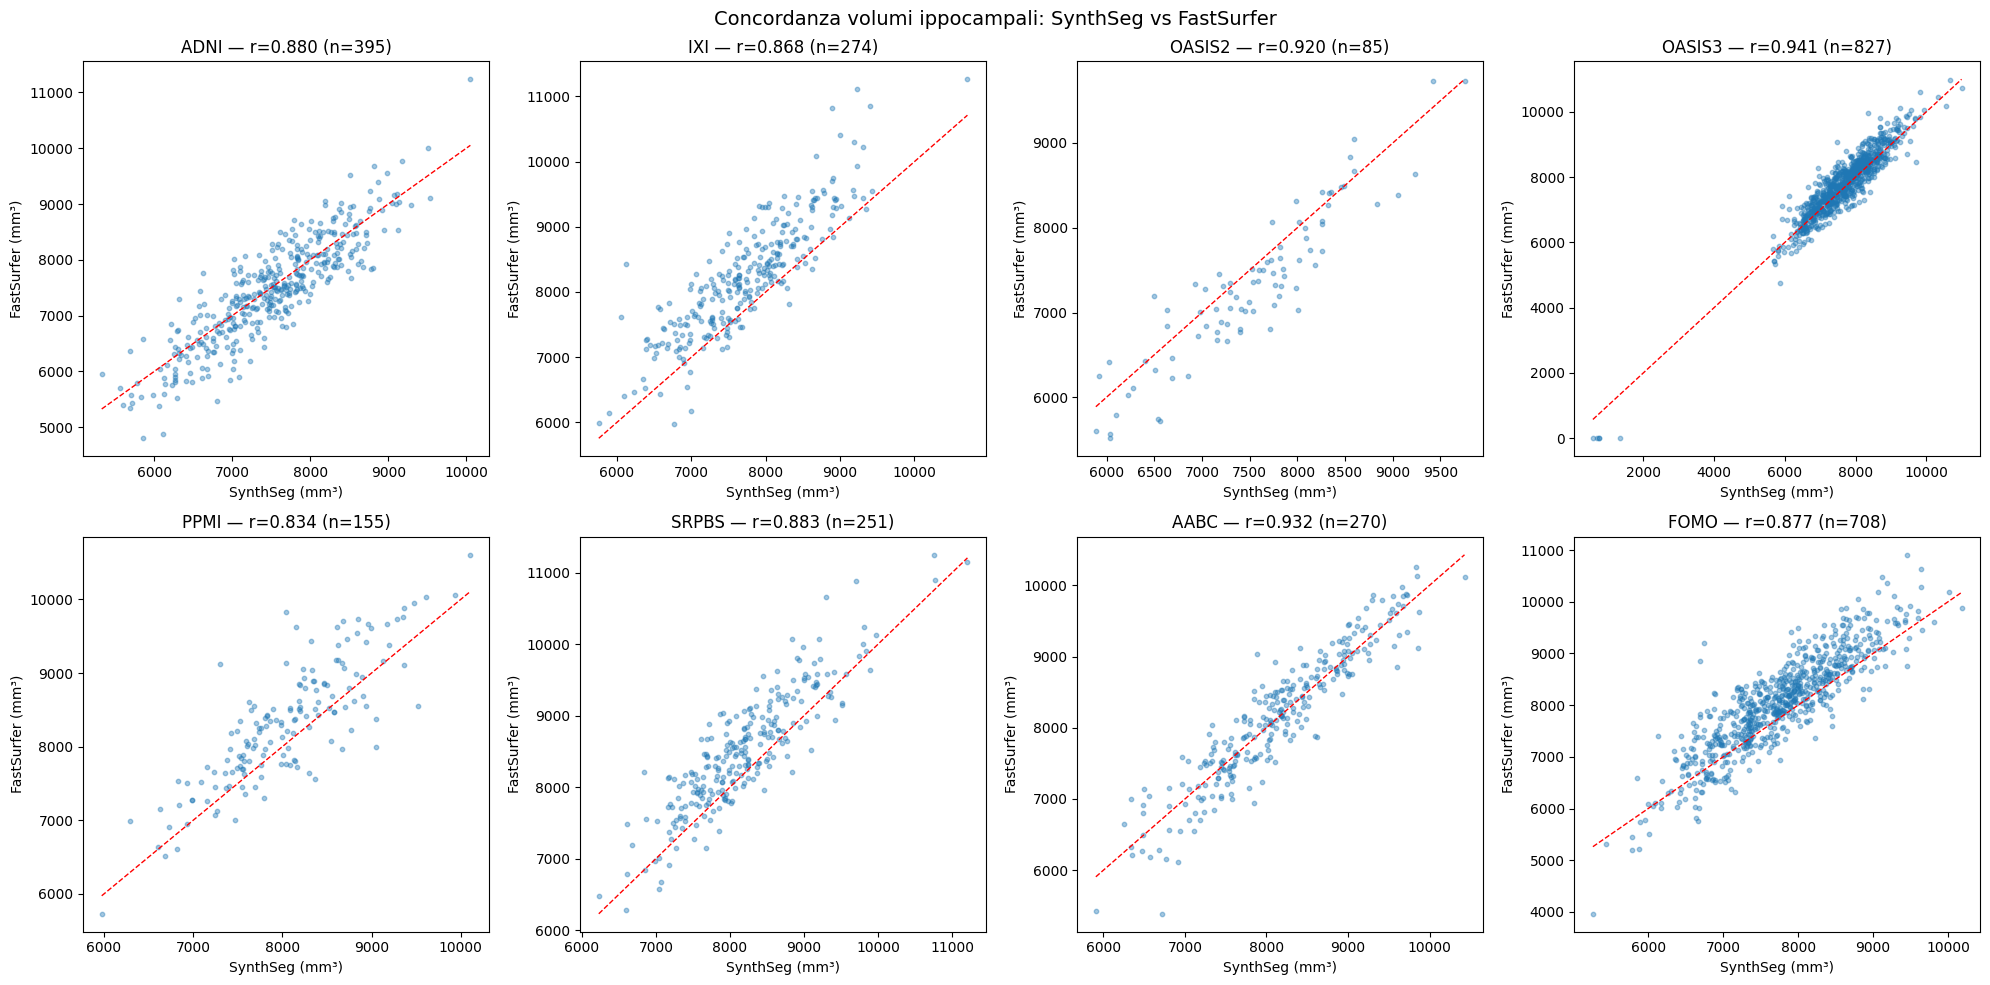

In [25]:
import matplotlib.pyplot as plt


def normalize_subject_for_merge(subject_id: object, dataset: str) -> str:
    """Normalizza gli ID soggetto tra metodi per il merge di confronto."""
    sid = str(subject_id).strip()
    if sid.startswith("sub-"):
        sid = sid[4:]

    ds = dataset.lower()
    if ds == "ixi":
        # Esempi: IXI123, sub-123, 123 -> IXI123
        digits = "".join(ch for ch in sid if ch.isdigit())
        return f"IXI{digits}" if digits else sid.upper()

    return sid


synthseg_files = {
    "adni":   "adni.csv",
    "ixi":    "ixi.csv",
    "oasis2": "oasis2.csv",
    "oasis3": "oasis3.csv",
    "ppmi":   "ppmi.csv",
    "srpbs":  "srpb.csv",
    "aabc":   "aabc.csv",
    "fomo":   "fomo.csv",
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (dataset, synthseg_file) in enumerate(synthseg_files.items()):
    ax = axes[i]

    if dataset not in aggregated:
        ax.set_title(f"{dataset.upper()} — assente in FastSurfer")
        ax.axis("off")
        continue

    synthseg_df = pd.read_csv(OUTPUT_DIR / synthseg_file)
    fastsurfer_df = aggregated[dataset]

    synthseg_comp = synthseg_df[["subject_id", "vol_left hippocampus", "vol_right hippocampus"]].copy()
    fastsurfer_comp = fastsurfer_df[["subject_id", "vol_left hippocampus", "vol_right hippocampus"]].copy()

    synthseg_comp["subject_key"] = synthseg_comp["subject_id"].apply(lambda x: normalize_subject_for_merge(x, dataset))
    fastsurfer_comp["subject_key"] = fastsurfer_comp["subject_id"].apply(lambda x: normalize_subject_for_merge(x, dataset))

    # Merge su chiave normalizzata (fix per formati ID eterogenei, es. IXI).
    merged = pd.merge(
        synthseg_comp,
        fastsurfer_comp,
        on="subject_key",
        suffixes=("_synthseg", "_fastsurfer")
    )

    if merged.empty:
        ax.set_title(f"{dataset.upper()} — nessun overlap")
        ax.axis("off")
        continue

    x = merged["vol_left hippocampus_synthseg"] + merged["vol_right hippocampus_synthseg"]
    y = merged["vol_left hippocampus_fastsurfer"] + merged["vol_right hippocampus_fastsurfer"]

    corr = x.corr(y)
    ax.scatter(x, y, alpha=0.4, s=10)
    ax.plot([x.min(), x.max()], [x.min(), x.max()], "r--", lw=1)
    ax.set_xlabel("SynthSeg (mm³)")
    ax.set_ylabel("FastSurfer (mm³)")
    ax.set_title(f"{dataset.upper()} — r={corr:.3f} (n={len(merged)})")

fig.suptitle("Concordanza volumi ippocampali: SynthSeg vs FastSurfer", fontsize=14)
plt.tight_layout()
plt.savefig("/home/mario/Repository/Normal_Alzeihmer/figures/synthseg_vs_fastsurfer_hippocampus.png",
            dpi=150, bbox_inches="tight")
plt.show()